# SoccerNet - Download camera calibration data

In [10]:
from SoccerNet.Downloader import SoccerNetDownloader

import os, json, cv2
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

True

#### Github Repository für die Kamera-Kalibrierung

https://github.com/SoccerNet/sn-calibration/tree/main

In [11]:
password = os.getenv("SOCCERNET_PASSWORD")
if password is None:
    raise ValueError("SOCCERNET_PASSWORD not found in environment variables")

downloader = SoccerNetDownloader(LocalDirectory="/data/manser/soccernet")
downloader.password = password

downloader.downloadDataTask(
    task="calibration-2023",
    split=["train", "valid", "test", "challenge"]
)

In [12]:
# Pfade
base_path = Path("/data/manser/soccernet/calibration-2023/train")
image_path = base_path / "16412.jpg"
json_path = base_path / "16412.json"
output_path = base_path / "16412_overlay.jpg"

In [13]:
# Bild laden
img = cv2.imread(str(image_path))
if img is None:
    raise FileNotFoundError(f"Bild nicht gefunden: {image_path}")

height, width = img.shape[:2]

# JSON laden
with open(json_path, "r") as f:
    annotations = json.load(f)

print("Annotierte Linien:")
for line_name in annotations.keys():
    print("-", line_name)

# Alle Linien durchgehen
for line_name, points in annotations.items():
    pixel_points = []

    for p in points:
        x_pixel = int(p["x"] * width)
        y_pixel = int(p["y"] * height)
        pixel_points.append((x_pixel, y_pixel))

        # Punkt einzeichnen
        cv2.circle(img, (x_pixel, y_pixel), 5, (0, 0, 255), -1)

    # Falls mindestens 2 Punkte vorhanden sind, Linie verbinden
    if len(pixel_points) >= 2:
        for i in range(len(pixel_points) - 1):
            cv2.line(img, pixel_points[i], pixel_points[i + 1], (0, 255, 0), 2)

# Bild speichern
cv2.imwrite(str(output_path), img)

print(f"\nInput-Bild: {image_path}")
print(f"\nOverlay gespeichert unter: {output_path}")

Annotierte Linien:
- Goal left post left 
- Goal left post right
- Goal left crossbar
- Side line left
- Side line top
- Big rect. left top
- Small rect. left top
- Small rect. left bottom
- Small rect. left main

Input-Bild: /data/manser/soccernet/calibration-2023/train/16412.jpg

Overlay gespeichert unter: /data/manser/soccernet/calibration-2023/train/16412_overlay.jpg


In [14]:
print("Anzahl annotierter Elemente:", len(annotations))
for key, value in annotations.items():
    print(f"{key}: {len(value)} Punkte")

Anzahl annotierter Elemente: 9
Goal left post left : 2 Punkte
Goal left post right: 2 Punkte
Goal left crossbar: 2 Punkte
Side line left: 2 Punkte
Side line top: 2 Punkte
Big rect. left top: 2 Punkte
Small rect. left top: 2 Punkte
Small rect. left bottom: 2 Punkte
Small rect. left main: 2 Punkte



Frame 16412
Verwendete Linien: ['Big rect. left top', 'Side line left', 'Side line top', 'Small rect. left bottom', 'Small rect. left main', 'Small rect. left top']


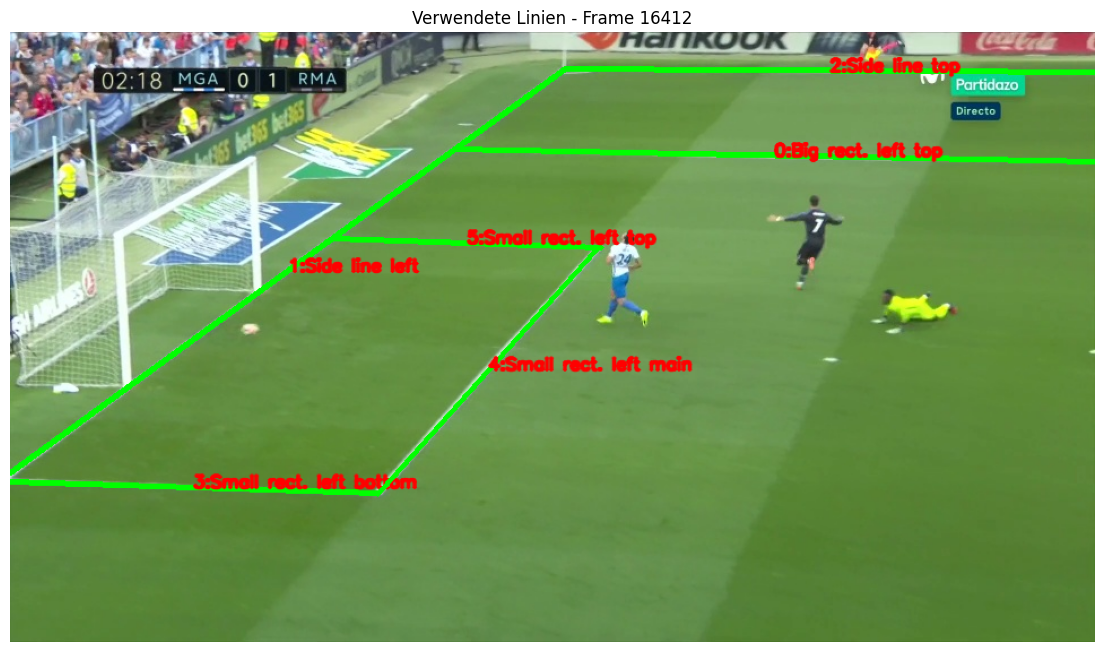

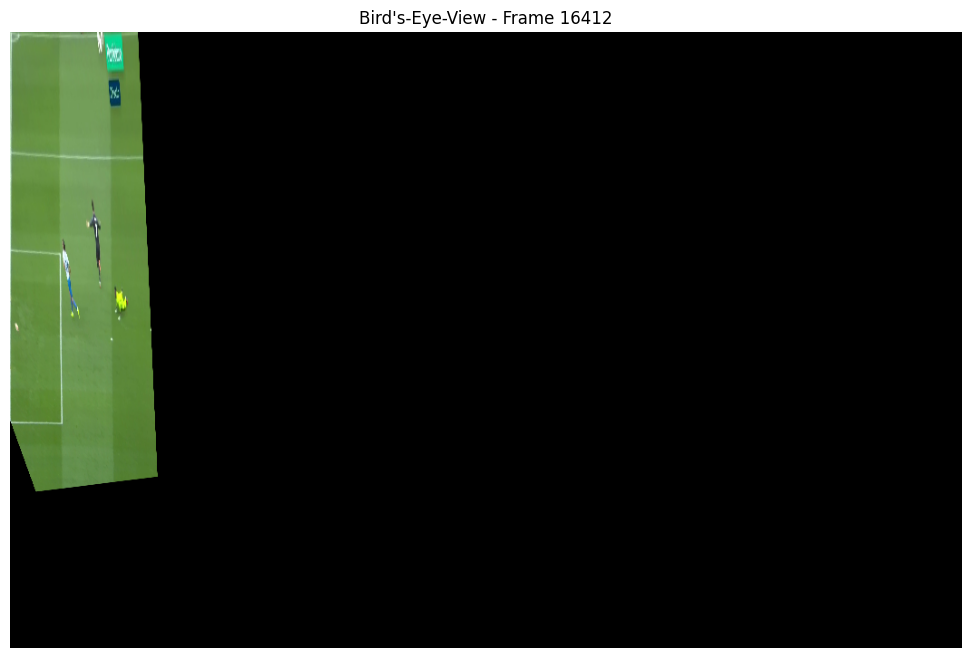

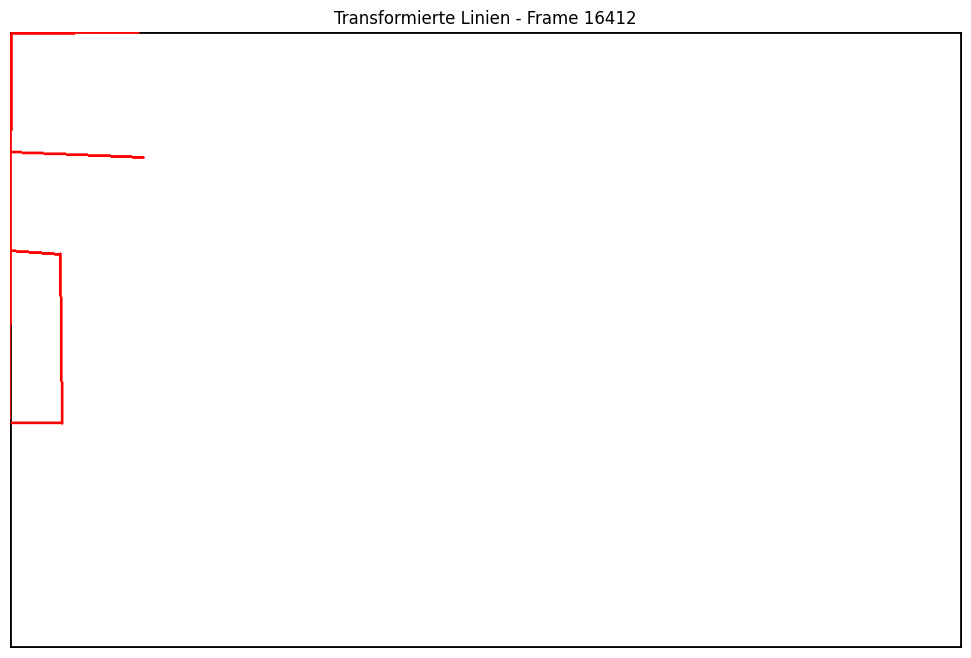


Frame 16433
Verwendete Linien: ['Big rect. right bottom', 'Big rect. right main', 'Big rect. right top', 'Side line right', 'Side line top', 'Small rect. right bottom', 'Small rect. right main', 'Small rect. right top']


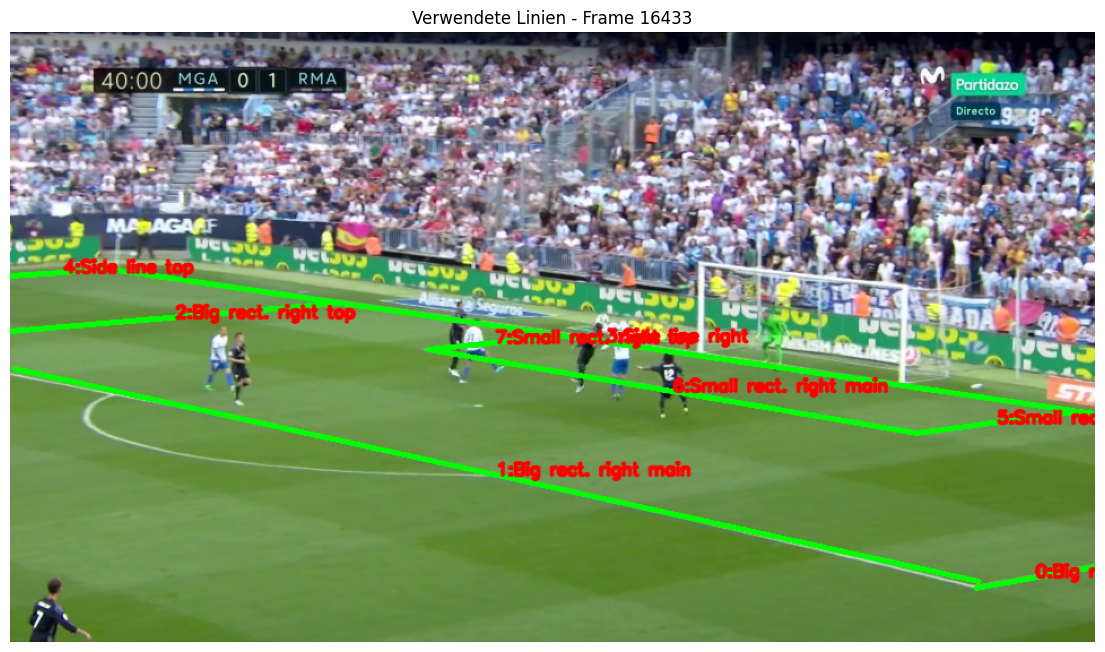

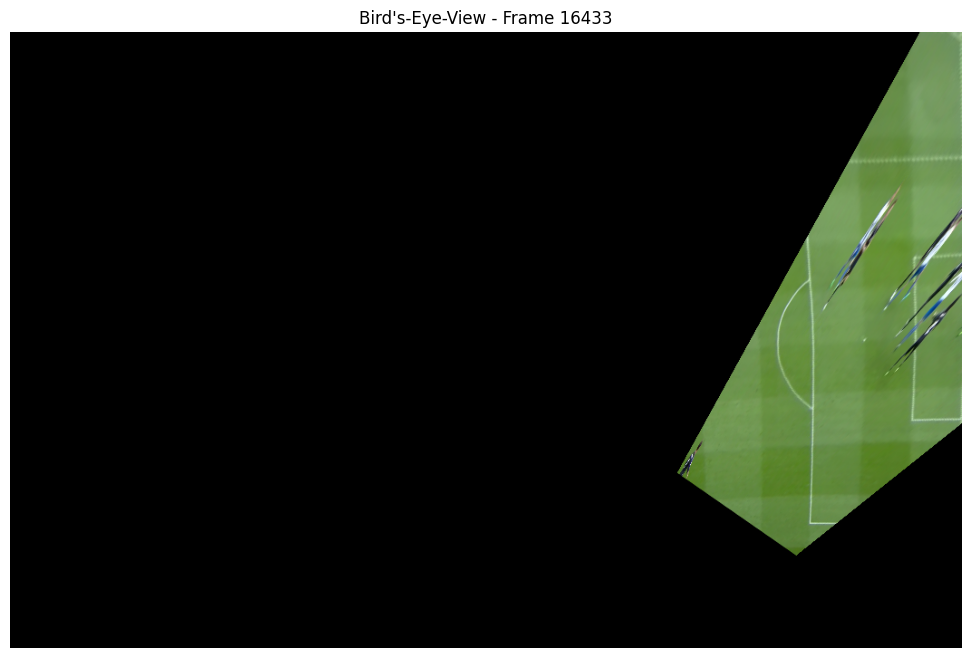

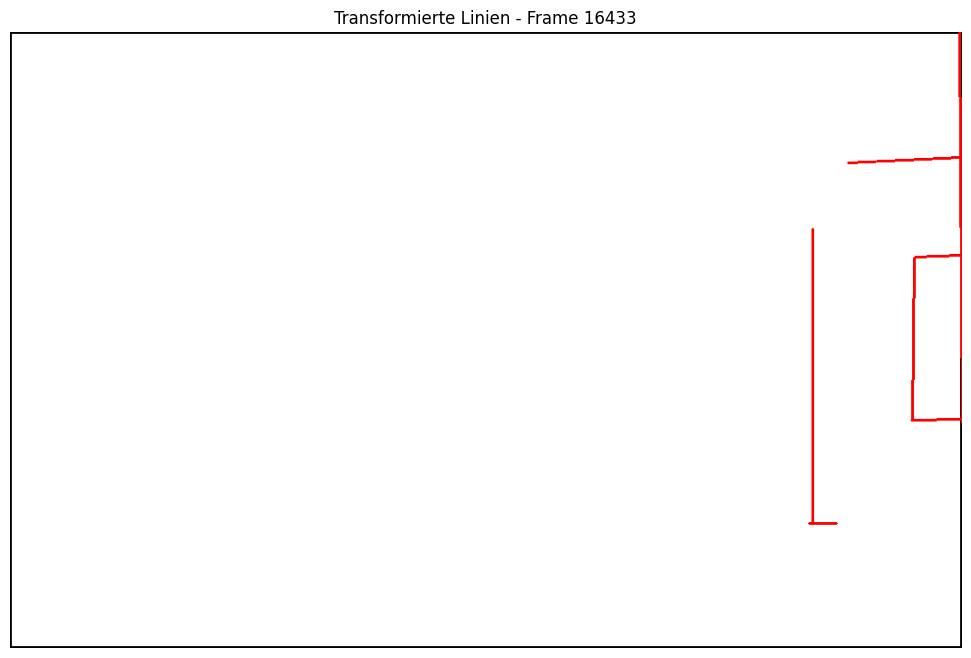


Frame 16434
Verwendete Linien: ['Big rect. right top', 'Small rect. right bottom', 'Small rect. right main', 'Small rect. right top']
Zu wenige Linien fuer eine stabile Homography.


In [2]:
import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# SoccerPitch - planare Version fuer Pitch-Kalibrierung
# Koordinatensystem:
# x: links -> rechts
# y: oben -> unten
# Ursprung: linke obere Ecke = (0, 0)
# ==================================================
class SoccerPitch:
    GOAL_LINE_TO_PENALTY_MARK = 11.0
    PENALTY_AREA_WIDTH = 40.32
    PENALTY_AREA_LENGTH = 16.5
    GOAL_AREA_WIDTH = 18.32
    GOAL_AREA_LENGTH = 5.5
    CENTER_CIRCLE_RADIUS = 9.15
    GOAL_HEIGHT = 2.44
    GOAL_LENGTH = 7.32

    PLANAR_LINE_CLASSES = [
        "Big rect. left bottom",
        "Big rect. left main",
        "Big rect. left top",
        "Big rect. right bottom",
        "Big rect. right main",
        "Big rect. right top",
        "Middle line",
        "Side line bottom",
        "Side line left",
        "Side line right",
        "Side line top",
        "Small rect. left bottom",
        "Small rect. left main",
        "Small rect. left top",
        "Small rect. right bottom",
        "Small rect. right main",
        "Small rect. right top",
    ]

    ANCHOR_LINES = {
        "Side line left",
        "Side line right",
        "Side line top",
        "Side line bottom",
        "Middle line",
    }

    def __init__(self, pitch_length=105.0, pitch_width=68.0):
        self.PITCH_LENGTH = pitch_length
        self.PITCH_WIDTH = pitch_width

        self.point_dict = {
            "TL_PITCH_CORNER": np.array([0.0, 0.0, 0.0]),
            "BL_PITCH_CORNER": np.array([0.0, pitch_width, 0.0]),
            "TR_PITCH_CORNER": np.array([pitch_length, 0.0, 0.0]),
            "BR_PITCH_CORNER": np.array([pitch_length, pitch_width, 0.0]),

            "T_MIDDLE": np.array([pitch_length / 2.0, 0.0, 0.0]),
            "B_MIDDLE": np.array([pitch_length / 2.0, pitch_width, 0.0]),

            # Linker Strafraum
            "L_PENALTY_AREA_TL_CORNER": np.array([0.0, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_TR_CORNER": np.array([self.PENALTY_AREA_LENGTH, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_BL_CORNER": np.array([0.0, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_BR_CORNER": np.array([self.PENALTY_AREA_LENGTH, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),

            # Rechter Strafraum
            "R_PENALTY_AREA_TL_CORNER": np.array([pitch_length - self.PENALTY_AREA_LENGTH, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_TR_CORNER": np.array([pitch_length, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_BL_CORNER": np.array([pitch_length - self.PENALTY_AREA_LENGTH, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_BR_CORNER": np.array([pitch_length, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),

            # Linker Fuenfmeterraum
            "L_GOAL_AREA_TL_CORNER": np.array([0.0, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_TR_CORNER": np.array([self.GOAL_AREA_LENGTH, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_BL_CORNER": np.array([0.0, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_BR_CORNER": np.array([self.GOAL_AREA_LENGTH, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),

            # Rechter Fuenfmeterraum
            "R_GOAL_AREA_TL_CORNER": np.array([pitch_length - self.GOAL_AREA_LENGTH, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_TR_CORNER": np.array([pitch_length, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_BL_CORNER": np.array([pitch_length - self.GOAL_AREA_LENGTH, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_BR_CORNER": np.array([pitch_length, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
        }

        self.line_extremities = {
            # Feld
            "Side line top": (
                self.point_dict["TL_PITCH_CORNER"],
                self.point_dict["TR_PITCH_CORNER"],
            ),
            "Side line bottom": (
                self.point_dict["BL_PITCH_CORNER"],
                self.point_dict["BR_PITCH_CORNER"],
            ),
            "Side line left": (
                self.point_dict["TL_PITCH_CORNER"],
                self.point_dict["BL_PITCH_CORNER"],
            ),
            "Side line right": (
                self.point_dict["TR_PITCH_CORNER"],
                self.point_dict["BR_PITCH_CORNER"],
            ),
            "Middle line": (
                self.point_dict["T_MIDDLE"],
                self.point_dict["B_MIDDLE"],
            ),

            # Linker Strafraum
            "Big rect. left top": (
                self.point_dict["L_PENALTY_AREA_TL_CORNER"],
                self.point_dict["L_PENALTY_AREA_TR_CORNER"],
            ),
            "Big rect. left bottom": (
                self.point_dict["L_PENALTY_AREA_BL_CORNER"],
                self.point_dict["L_PENALTY_AREA_BR_CORNER"],
            ),
            "Big rect. left main": (
                self.point_dict["L_PENALTY_AREA_TR_CORNER"],
                self.point_dict["L_PENALTY_AREA_BR_CORNER"],
            ),

            # Rechter Strafraum
            "Big rect. right top": (
                self.point_dict["R_PENALTY_AREA_TL_CORNER"],
                self.point_dict["R_PENALTY_AREA_TR_CORNER"],
            ),
            "Big rect. right bottom": (
                self.point_dict["R_PENALTY_AREA_BL_CORNER"],
                self.point_dict["R_PENALTY_AREA_BR_CORNER"],
            ),
            "Big rect. right main": (
                self.point_dict["R_PENALTY_AREA_TL_CORNER"],
                self.point_dict["R_PENALTY_AREA_BL_CORNER"],
            ),

            # Linker Fuenfmeterraum
            "Small rect. left top": (
                self.point_dict["L_GOAL_AREA_TL_CORNER"],
                self.point_dict["L_GOAL_AREA_TR_CORNER"],
            ),
            "Small rect. left bottom": (
                self.point_dict["L_GOAL_AREA_BL_CORNER"],
                self.point_dict["L_GOAL_AREA_BR_CORNER"],
            ),
            "Small rect. left main": (
                self.point_dict["L_GOAL_AREA_TR_CORNER"],
                self.point_dict["L_GOAL_AREA_BR_CORNER"],
            ),

            # Rechter Fuenfmeterraum
            "Small rect. right top": (
                self.point_dict["R_GOAL_AREA_TL_CORNER"],
                self.point_dict["R_GOAL_AREA_TR_CORNER"],
            ),
            "Small rect. right bottom": (
                self.point_dict["R_GOAL_AREA_BL_CORNER"],
                self.point_dict["R_GOAL_AREA_BR_CORNER"],
            ),
            "Small rect. right main": (
                self.point_dict["R_GOAL_AREA_TL_CORNER"],
                self.point_dict["R_GOAL_AREA_BL_CORNER"],
            ),
        }

    def get_2d_homogeneous_line(self, line_name):
        if line_name not in self.line_extremities:
            return None

        extremities = self.line_extremities[line_name]
        p1 = np.array([extremities[0][0], extremities[0][1], 1.0], dtype=np.float64)
        p2 = np.array([extremities[1][0], extremities[1][1], 1.0], dtype=np.float64)

        line = np.cross(p1, p2)
        n = np.linalg.norm(line[:2])
        if n > 0:
            line = line / n
        return line


# ==================================================
# Hilfsfunktionen
# ==================================================
def norm_to_pixel(p, width, height):
    return np.array([p["x"] * width, p["y"] * height], dtype=np.float64)


def get_segment(name, ann, width, height):
    pts = ann[name]
    if len(pts) != 2:
        raise ValueError(f"{name} hat nicht genau 2 Punkte.")
    p1 = norm_to_pixel(pts[0], width, height)
    p2 = norm_to_pixel(pts[1], width, height)
    return p1, p2


def line_from_points(p1, p2):
    hp1 = np.array([p1[0], p1[1], 1.0], dtype=np.float64)
    hp2 = np.array([p2[0], p2[1], 1.0], dtype=np.float64)
    l = np.cross(hp1, hp2)
    n = np.linalg.norm(l[:2])
    if n > 0:
        l = l / n
    return l


def normalization_transform(points):
    points = np.asarray(points, dtype=np.float64)
    center = np.mean(points, axis=0)

    d = 0.0
    nelems = 0
    for p in points:
        nelems += 1
        di = np.linalg.norm(p - center)
        d += (di - d) / nelems

    s = 1.0 if d <= 0 else np.sqrt(2) / d

    T = np.zeros((3, 3), dtype=np.float64)
    T[0, 0] = s
    T[0, 2] = -s * center[0]
    T[1, 1] = s
    T[1, 2] = -s * center[1]
    T[2, 2] = 1.0
    return T


def estimate_homography_from_line_correspondences(lines, T1=np.eye(3), T2=np.eye(3)):
    H = np.eye(3, dtype=np.float64)
    A = np.zeros((len(lines) * 2, 9), dtype=np.float64)

    for i, (src_line_raw, target_line_raw) in enumerate(lines):
        src_line = np.transpose(np.linalg.inv(T1)) @ src_line_raw
        target_line = np.transpose(np.linalg.inv(T2)) @ target_line_raw

        u, v, w = src_line
        x, y, z = target_line

        A[2 * i, 0] = 0
        A[2 * i, 1] = x * w
        A[2 * i, 2] = -x * v
        A[2 * i, 3] = 0
        A[2 * i, 4] = y * w
        A[2 * i, 5] = -v * y
        A[2 * i, 6] = 0
        A[2 * i, 7] = z * w
        A[2 * i, 8] = -v * z

        A[2 * i + 1, 0] = x * w
        A[2 * i + 1, 1] = 0
        A[2 * i + 1, 2] = -x * u
        A[2 * i + 1, 3] = y * w
        A[2 * i + 1, 4] = 0
        A[2 * i + 1, 5] = -u * y
        A[2 * i + 1, 6] = z * w
        A[2 * i + 1, 7] = 0
        A[2 * i + 1, 8] = -u * z

    _, s, vh = np.linalg.svd(A)
    if s[-1] <= 0:
        return False, H

    v = np.reshape(vh[-1], (3, 3))
    H = np.linalg.inv(T2) @ v @ T1

    if abs(H[2, 2]) > 1e-12:
        H /= H[2, 2]

    return True, H


def draw_segment(img, p1, p2, color=(0, 255, 0), thickness=2):
    p1 = np.asarray(p1, dtype=np.float64)
    p2 = np.asarray(p2, dtype=np.float64)

    if p1.shape[0] != 2 or p2.shape[0] != 2:
        return

    if not np.all(np.isfinite(p1)) or not np.all(np.isfinite(p2)):
        return

    p1i = tuple(np.round(p1).astype(int).tolist())
    p2i = tuple(np.round(p2).astype(int).tolist())

    cv2.line(img, p1i, p2i, color, thickness)


def transform_point(H, p):
    hp = np.array([p[0], p[1], 1.0], dtype=np.float64)
    q = H @ hp

    if abs(q[2]) < 1e-12:
        return np.array([np.nan, np.nan], dtype=np.float64)

    q /= q[2]
    return np.array([q[0], q[1]], dtype=np.float64)


# ==================================================
# Frame-Funktion
# ==================================================
def calibrate_and_visualize_frame(frame_id, base_path, pitch, scale=10):
    image_path = base_path / f"{frame_id}.jpg"
    json_path = base_path / f"{frame_id}.json"

    if not image_path.exists() or not json_path.exists():
        print(f"\nFrame {frame_id}: Datei fehlt.")
        return None, None

    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_bgr.shape[:2]

    with open(json_path, "r") as f:
        annotations = json.load(f)

    # Nur planare Linien mit genau 2 Punkten verwenden
    used_line_names = [
        name for name in pitch.PLANAR_LINE_CLASSES
        if name in annotations and len(annotations[name]) == 2
    ]

    print(f"\nFrame {frame_id}")
    print("Verwendete Linien:", used_line_names)

    # Mindestanforderungen
    if len(used_line_names) < 5:
        print("Zu wenige Linien fuer eine stabile Homography.")
        return None, None

    anchor_count = len(set(used_line_names).intersection(pitch.ANCHOR_LINES))
    if anchor_count == 0:
        print("Keine stabile Ankerlinie (Side/Middle line) vorhanden.")
        return None, None

    image_segments = {}
    for name in used_line_names:
        image_segments[name] = get_segment(name, annotations, img_w, img_h)

    line_matches = []
    src_pts = []
    target_pts = []

    for name in used_line_names:
        pitch_line = pitch.get_2d_homogeneous_line(name)
        if pitch_line is None:
            continue

        ip1, ip2 = image_segments[name]
        image_line = line_from_points(ip1, ip2)

        line_matches.append((pitch_line, image_line))

        pp1_3d, pp2_3d = pitch.line_extremities[name]
        pp1 = np.array([pp1_3d[0], pp1_3d[1]], dtype=np.float64)
        pp2 = np.array([pp2_3d[0], pp2_3d[1]], dtype=np.float64)

        src_pts.extend([pp1, pp2])
        target_pts.extend([ip1, ip2])

    if len(line_matches) < 4:
        print("Zu wenige gueltige Linienkorrespondenzen.")
        return None, None

    src_pts = np.asarray(src_pts, dtype=np.float64)
    target_pts = np.asarray(target_pts, dtype=np.float64)

    T_pitch = normalization_transform(src_pts)
    T_img = normalization_transform(target_pts)

    success, H_pitch_to_image = estimate_homography_from_line_correspondences(
        line_matches, T1=T_pitch, T2=T_img
    )

    if not success:
        print("Homography konnte nicht geschaetzt werden.")
        return None, None

    try:
        H_image_to_pitch = np.linalg.inv(H_pitch_to_image)
    except np.linalg.LinAlgError:
        print("Homography nicht invertierbar.")
        return None, None

    if abs(H_image_to_pitch[2, 2]) < 1e-12:
        print("Homography numerisch instabil.")
        return None, None

    H_image_to_pitch /= H_image_to_pitch[2, 2]

    # --------------------------------------------------
    # 1) Verwendete Linien im Bild
    # --------------------------------------------------
    img_vis = img_rgb.copy()

    for idx, name in enumerate(used_line_names):
        p1, p2 = image_segments[name]
        draw_segment(img_vis, p1, p2, color=(0, 255, 0), thickness=3)

        mid = (p1 + p2) / 2.0
        if np.all(np.isfinite(mid)):
            cv2.putText(
                img_vis,
                f"{idx}:{name}",
                tuple(np.round(mid).astype(int).tolist()),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                2,
                cv2.LINE_AA,
            )

    plt.figure(figsize=(14, 8))
    plt.imshow(img_vis)
    plt.title(f"Verwendete Linien - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------
    # 2) Bird's-Eye-View
    # --------------------------------------------------
    pitch_w_px = int(pitch.PITCH_LENGTH * scale)
    pitch_h_px = int(pitch.PITCH_WIDTH * scale)

    S = np.array([
        [scale, 0, 0],
        [0, scale, 0],
        [0, 0, 1]
    ], dtype=np.float64)

    H_image_to_pitch_scaled = S @ H_image_to_pitch

    bird = cv2.warpPerspective(
        img_rgb,
        H_image_to_pitch_scaled,
        (pitch_w_px, pitch_h_px)
    )

    plt.figure(figsize=(14, 8))
    plt.imshow(bird)
    plt.title(f"Bird's-Eye-View - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------
    # 3) Transformierte Linien auf leerem Pitch
    # --------------------------------------------------
    pitch_canvas = np.ones((pitch_h_px, pitch_w_px, 3), dtype=np.uint8) * 255
    cv2.rectangle(pitch_canvas, (0, 0), (pitch_w_px - 1, pitch_h_px - 1), (0, 0, 0), 2)

    invalid_segments = 0

    for name in used_line_names:
        p1, p2 = image_segments[name]
        q1 = transform_point(H_image_to_pitch_scaled, p1)
        q2 = transform_point(H_image_to_pitch_scaled, p2)

        if not np.all(np.isfinite(q1)) or not np.all(np.isfinite(q2)):
            print(f"{frame_id}: ungueltige transformierte Punkte bei {name}")
            invalid_segments += 1
            continue

        draw_segment(pitch_canvas, q1, q2, color=(255, 0, 0), thickness=2)

    plt.figure(figsize=(14, 8))
    plt.imshow(pitch_canvas)
    plt.title(f"Transformierte Linien - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    if invalid_segments > 0:
        print(f"{frame_id}: {invalid_segments} Segmente konnten nicht gezeichnet werden.")

    return H_image_to_pitch, H_image_to_pitch_scaled


# ==================================================
# Anwendung
# ==================================================
base_path = Path("/data/manser/soccernet/calibration-2023/train")
pitch = SoccerPitch(105.0, 68.0)

results = {}

for frame_id in ["16412", "16433", "16434"]:
    H_meter, H_scaled = calibrate_and_visualize_frame(frame_id, base_path, pitch, scale=10)
    results[frame_id] = {
        "H_image_to_pitch": H_meter,
        "H_image_to_pitch_scaled": H_scaled,
    }